In [1]:

import argparse
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
def age_group(row):
    age = float(row["anchor_age"])

    if age < 20:
        return "0-20"
    elif age <= 40:
        return "20-40"
    elif age <= 60:
        return "40-60"
    elif age <= 80:
        return "60-80"
    else:
        return "80+"
def stratify_group(row):
    # Combine demographic and label attributes into a single stratification key
    attrs = [
        str(row["gender"]).strip().upper() if pd.notna(row["gender"]) else "UNK",
        str(row["ethnicity"]).strip().upper() if pd.notna(row["ethnicity"]) else "UNK",
        str(age_group(row)).strip().upper() if pd.notna(row["anchor_age"]) else "UNK",
    ]
    # # Include label info if available
    # label_cols = [
    #     "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    #     "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion", "Lung Opacity",
    #     "Pleural Effusion", "Pneumonia", "Pneumothorax", "Support Devices"
    # ]
    # positive_labels = [col for col in label_cols if row.get(col) == 1.0]
    # if not positive_labels:
    #     attrs.append("NoFinding")
    # else:
    #     attrs.append("+".join(sorted(positive_labels)))
    return "_".join(attrs)


In [ ]:
source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512

original_metadata_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv")

# Drop rows where ethnicity is NaN or one of the specified values
ethnicity_to_drop = ['UNKNOWN', 'OTHER', 'UNABLE TO OBTAIN','AMERICAN INDIAN/ALASKA NATIVE']
metadata_df = original_metadata_df.dropna(subset=['ethnicity'])
metadata_df = metadata_df[~metadata_df['ethnicity'].isin(ethnicity_to_drop)]


# Drop rows where view position is not PA or AP
view_position_to_keep = ['AP','PA','LATERAL', 'LL']
metadata_df = metadata_df.dropna(subset=['ViewPosition'])
metadata_df = metadata_df[metadata_df['ViewPosition'].isin(view_position_to_keep)]


def age_to_group(age):

    if age < 18:
        return "0-18"
    elif age <= 40:
        return "18-40"
    elif age <= 60:
        return "40-60"
    elif age <= 80:
        return "60-80"
    else:
        return "80+"
metadata_df['age_group'] = metadata_df['anchor_age'].apply(age_to_group)



chexpert_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-chexpert.csv")
merged_df = pd.merge(metadata_df, chexpert_df, on=["subject_id", "study_id"], how="inner")


# # Replace ethnicity values with simplified categories
# ethnicity_mapping = {
#     'WHITE': 'white',
#     'HISPANIC/LATINO': 'Hispanic', 
#     'BLACK/AFRICAN AMERICAN': 'Black',
#     'AMERICAN INDIAN/ALASKA NATIVE': 'Native'
# }

# merged_df['ethnicity'] = merged_df['ethnicity'].map(ethnicity_mapping)


# Create stratification key
merged_df["stratify_key"] = merged_df.apply(stratify_group, axis=1)


In [30]:
merged_df['ViewPosition'].value_counts(dropna=False)

ViewPosition
AP         128799
PA          78618
LATERAL     68088
LL          31127
Name: count, dtype: int64

In [6]:
PA_data['ethnicity'].value_counts(dropna=False)

ethnicity
WHITE                            52777
BLACK/AFRICAN AMERICAN           16499
HISPANIC/LATINO                   6240
ASIAN                             2931
AMERICAN INDIAN/ALASKA NATIVE      171
Name: count, dtype: int64

In [7]:
PA_data = merged_df[merged_df['ViewPosition'] == 'PA']
counts = PA_data[['stratify_key']].value_counts(dropna=False)
counts

stratify_key                  
M_WHITE_60-80                     12721
M_WHITE_40-60                     10860
F_WHITE_60-80                      9197
F_WHITE_40-60                      7547
F_BLACK/AFRICAN AMERICAN_40-60     4191
F_WHITE_20-40                      3255
M_WHITE_20-40                      3102
M_BLACK/AFRICAN AMERICAN_40-60     3063
F_BLACK/AFRICAN AMERICAN_60-80     3030
M_WHITE_80+                        2938
F_WHITE_80+                        2878
F_BLACK/AFRICAN AMERICAN_20-40     2213
M_BLACK/AFRICAN AMERICAN_60-80     2062
F_HISPANIC/LATINO_40-60            1501
M_HISPANIC/LATINO_40-60            1291
M_BLACK/AFRICAN AMERICAN_20-40     1092
F_HISPANIC/LATINO_20-40             909
F_HISPANIC/LATINO_60-80             890
M_HISPANIC/LATINO_60-80             742
M_HISPANIC/LATINO_20-40             676
F_ASIAN_60-80                       601
M_ASIAN_60-80                       587
M_ASIAN_40-60                       520
F_ASIAN_40-60                       489
F_BLACK/A

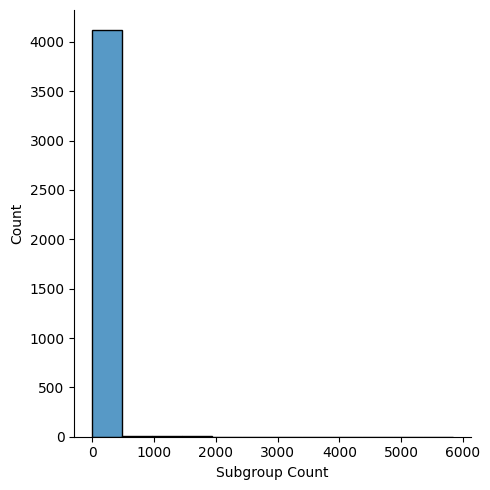

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# PA_data = merged_df[merged_df['ViewPosition'] == 'PA']
# counts = PA_data[['gender', 'ethnicity', 'age_group']].value_counts(dropna=False)


sns.displot(counts, binwidth=500)
plt.xlabel('Subgroup Size')
plt.xlabel('Subgroup Count')

plt.show()

In [ ]:
83232

In [6]:
merged_df[merged_df['ViewPosition'] == 'PA']

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,...,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,stratify_key
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,F_WHITE_40-60
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,F_WHITE_40-60
14,c50494f1-90e2bff5-e9189550-1a4562fd-6ab5204c,10000935,55697293,NaN,PA,2022,1840,21870226,85443.000,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,F_BLACK/AFRICAN AMERICAN_40-60
18,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,10000935,56522600,NaN,PA,2022,1736,21860730,155005.000,CHEST (PA AND LAT),...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F_BLACK/AFRICAN AMERICAN_40-60
20,6ad03ed1-97ee17ee-9cf8b320-f7011003-cd93b42d,10000980,50985099,NaN,PA,2022,1870,21910917,130354.000,CHEST (PA AND LAT),...,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,F_BLACK/AFRICAN AMERICAN_60-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306615,4750f069-a4a2b152-61dadb2b-8e7c09a6-1c0578c2,19999068,52434977,Performed Desc,PA,1617,1770,21610831,101338.000,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,M_WHITE_60-80
306616,8dc9f5e1-14887015-8db378ef-2fd4441a-d45ee0f3,19999156,50847545,CHEST (PA AND LAT),PA,3056,2544,21230127,145009.656,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,F_WHITE_60-80
306624,5a5eddf4-b64e5e49-f6e9c8bc-d6409b00-015470ea,19999287,53282218,NaN,PA,2022,1606,21961127,112117.000,CHEST (PA AND LAT),...,NaN,-1.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN,F_BLACK/AFRICAN AMERICAN_60-80
306629,3fcd0406-9b111603-feae7033-96632b3a-111333e5,19999733,57132437,CHEST (PA AND LAT),PA,3056,2544,21520708,224550.171,CHEST (PA AND LAT),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,F_WHITE_0-20


subject_id represents the patients. A patient might have more than one report.

study_id represents the radiological report, which can correspond to one or more images.

dicom_id represents the single image. 


| Step | Images | Radiology Reports | Patients | Notes |
|------|--------|-------------------|----------|-------|
| Original | 377,110 | 227,835 | 65,379 | - |
| With CheXpert labels | 377,095 | 227,827 | 65,379 | 15 images missing labels |
| After dropping missing ethnicities | 319,576 | 194,120 | 49,297 | 57534 Images without known ethnicities |
| After dropping unknown view positions | 306,632 | 188,112 | 48,552 | 12944 Images without known ethnicities |

In [3]:
merged_df['gender'].value_counts(dropna=False)

gender
M    160081
F    146551
Name: count, dtype: int64

In [4]:
merged_df['ViewPosition'].value_counts(dropna=False)


ViewPosition
AP         128799
PA          78618
LATERAL     68088
LL          31127
Name: count, dtype: int64

In [5]:
merged_df['age_group'].value_counts(dropna=False)

age_group
60-80    126551
40-60     99998
80+       43561
20-40     35166
0-20       1356
Name: count, dtype: int64

In [6]:
merged_df['ethnicity'].value_counts(dropna=False)

ethnicity
WHITE                            217246
BLACK/AFRICAN AMERICAN            57768
HISPANIC/LATINO                   19758
ASIAN                             10950
AMERICAN INDIAN/ALASKA NATIVE       910
Name: count, dtype: int64

In [7]:
merged_df['stratify_key'].value_counts()

stratify_key
M_WHITE_60-80                            54435
F_WHITE_60-80                            40398
M_WHITE_40-60                            39009
F_WHITE_40-60                            26422
F_WHITE_80+                              19383
M_WHITE_80+                              16980
F_BLACK/AFRICAN AMERICAN_40-60           12972
F_BLACK/AFRICAN AMERICAN_60-80           12426
M_WHITE_20-40                             9996
M_BLACK/AFRICAN AMERICAN_40-60            9839
F_WHITE_20-40                             9809
M_BLACK/AFRICAN AMERICAN_60-80            8377
F_BLACK/AFRICAN AMERICAN_20-40            5689
M_HISPANIC/LATINO_40-60                   4054
F_HISPANIC/LATINO_40-60                   3997
M_BLACK/AFRICAN AMERICAN_20-40            3572
F_HISPANIC/LATINO_60-80                   3159
F_BLACK/AFRICAN AMERICAN_80+              3105
M_HISPANIC/LATINO_60-80                   2739
M_ASIAN_60-80                             2473
M_HISPANIC/LATINO_20-40                   2345


In [18]:
merged_df.shape[0]*0.5

153316.0

In [8]:
valtest_df['stratify_key'].value_counts()

NameError: name 'valtest_df' is not defined

In [9]:
merged_df['report'] = merged_df['study_id'].apply(lambda x: raw_dir / 'report_sentences' / f"s{int(x)}.json")

merged_df['image'] = merged_df.apply(
    lambda row: f"{raw_dir}/files/p{str(int(row['subject_id']))[:2]}/p{str(int(row['subject_id']))}/"
    f"s{int(row['study_id'])}/{row['dicom_id']}.jpg", 
    axis=1)


In [14]:
output_dir = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/split_data"
val_size = 0.05
test_size = 0.45
random_state = 42

# Initial split: Train vs (Val + Test)
train_df, valtest_df = train_test_split(
    merged_df,
    test_size=val_size + test_size,
    stratify=merged_df["stratify_key"],
    random_state=random_state,
)

# Filter out classes with only 1 member to avoid stratification error
stratify_counts = valtest_df["stratify_key"].value_counts()
valid_strata = stratify_counts[stratify_counts >= 2].index
filtered_valtest_df = valtest_df[valtest_df["stratify_key"].isin(valid_strata)]
print(f"Filtered out {len(valtest_df) - len(filtered_valtest_df)} samples with rare classes (only 1 member)")

# Secondary split: Val vs Test
val_df, test_df = train_test_split(
    filtered_valtest_df,
    test_size=test_size / (val_size + test_size),
    stratify=filtered_valtest_df["stratify_key"],
    random_state=random_state,
)



Filtered out 1 samples with rare classes (only 1 member)


In [22]:
val_df.columns

Index(['dicom_id', 'subject_id', 'study_id',
       'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns',
       'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning',
       'ViewCodeSequence_CodeMeaning',
       'PatientOrientationCodeSequence_CodeMeaning', 'gender', 'anchor_age',
       'ethnicity', 'age_group', 'Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',
       'stratify_key', 'report', 'image'],
      dtype='object')

In [26]:

# Output TSVs
output_path = Path(output_dir)
output_path.mkdir(parents=True, exist_ok=True)
columns_to_keep = ["subject_id", "study_id",'ViewPosition','gender', 'ethnicity', 'age_group',
 'Atelectasis', 'Cardiomegaly', 'Consolidation',
  'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
   'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
    'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',
     'stratify_key', 'report', 'image']
train_df[columns_to_keep].to_csv(output_path / "train.tsv", sep="\t", index=False)
val_df[columns_to_keep].to_csv(output_path / "validation.tsv", sep="\t", index=False)
test_df[columns_to_keep].to_csv(output_path / "test.tsv", sep="\t", index=False)

# Save split information to text file
split_info_path = output_path / "split_info.txt"
with open(split_info_path, 'w') as f:
    f.write("Dataset Split Information\n")
    f.write("=" * 30 + "\n\n")
    f.write(f"Random State: {random_state}\n\n")
    f.write("Proportions:\n")
    f.write(f"  Train: {1 - (val_size + test_size):.1%}\n")
    f.write(f"  Validation: {val_size:.1%}\n")
    f.write(f"  Test: {test_size:.1%}\n\n")
    f.write("Actual Sizes:\n")
    f.write(f"  Train: {len(train_df):,} samples\n")
    f.write(f"  Validation: {len(val_df):,} samples\n")
    f.write(f"  Test: {len(test_df):,} samples\n")
    f.write(f"  Total: {len(train_df) + len(val_df) + len(test_df):,} samples\n")

print(f"Saved {len(train_df)} training, {len(val_df)} validation, and {len(test_df)} test samples.")
print(f"Split information saved to: {split_info_path}")

Saved 153316 training, 15331 validation, and 137984 test samples.
Split information saved to: /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/split_data/split_info.txt
